In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchaudio
import torchaudio.transforms as T

# Project root and data path (DCASE layout: root/pump/train/*.wav or root/pump/test/*.wav)
_cwd = Path(".").resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = Path("/mnt/ssd/LaCie/dcase2020_task2/dcase2020_task2_dev_dataset")
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "data/dcase2020-task2-dev-dataset"

SAMPLE_RATE = 16_000
N_FFT = 1024
HOP_LENGTH = 512
N_MELS = 128
F_MIN = 0.0
F_MAX = 8000.0

# Load one pump audio file (train or test)
pump_train = DATA_PATH / "valve" / "train"
pump_test = DATA_PATH / "valve" / "test"
wav_files = list((pump_train if pump_train.exists() else pump_test).glob("*.wav"))
if not wav_files:
    raise FileNotFoundError(f"No .wav files under {DATA_PATH}/pump/train or .../test. Set DATA_PATH.")

audio_path = wav_files[0]
waveform, sr = torchaudio.load(audio_path)
if sr != SAMPLE_RATE:
    waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
if waveform.shape[0] > 1:
    waveform = waveform.mean(0, keepdim=True)

waveform = waveform.squeeze(0).numpy()  # (T,)
t = np.arange(len(waveform)) / SAMPLE_RATE
wav_tensor = torch.from_numpy(waveform).unsqueeze(0)

# Spectrogram (linear freq, linear magnitude)
spec_transform = T.Spectrogram(n_fft=N_FFT, hop_length=HOP_LENGTH, power=2)
spec_linear = spec_transform(wav_tensor).squeeze(0).numpy()  # (n_freq, n_time)
n_freq, n_time = spec_linear.shape
freq_Hz = np.linspace(0, SAMPLE_RATE / 2, n_freq)
time_s = np.arange(n_time) * HOP_LENGTH / SAMPLE_RATE

# Mel and log-mel
mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH,
    n_mels=N_MELS, f_min=F_MIN, f_max=F_MAX, power=2,
)
to_db = T.AmplitudeToDB(top_db=80.0)
# clamp minimum to -100 dB
to_db = torch.clamp(to_db, min=-80.0)
mel_spec = mel_transform(wav_tensor).squeeze(0).numpy()
log_mel_spec = to_db(mel_transform(wav_tensor)).squeeze(0).numpy()

# log_mel_spec = (log_mel_spec - log_mel_spec.mean(axis=0, keepdims=True)) / log_mel_spec.std(axis=0, keepdims=True)

# Linear spectrogram with logarithmic (dB) magnitude
log_spec_linear = to_db(torch.from_numpy(spec_linear).unsqueeze(0)).squeeze(0).numpy()
time_edges = np.arange(n_time + 1) * HOP_LENGTH / SAMPLE_RATE

print(f"Loaded: {audio_path.name}, length = {len(waveform) / SAMPLE_RATE:.2f} s, sr = {SAMPLE_RATE}")

Loaded: normal_id_00_00000376.wav, length = 10.00 s, sr = 16000


## Time–amplitude and linear spectrogram

Top: raw time–amplitude signal. Bottom: spectrogram (linear frequency, linear magnitude; no mel, no log).

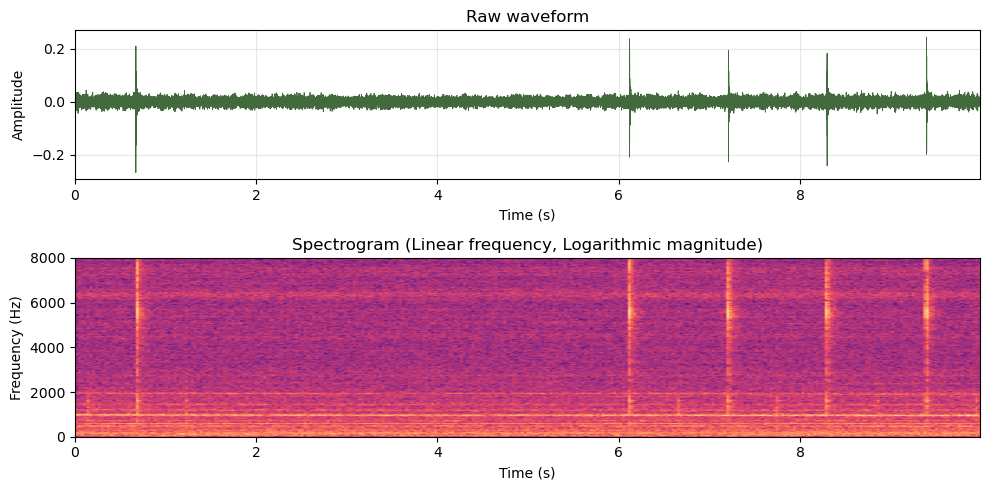

In [13]:
fig, (ax_top, ax_spec) = plt.subplots(2, 1, figsize=(10, 5), height_ratios=[1, 1.2], sharex=True)

ax_top.plot(t, waveform, color="#2d5a27", linewidth=0.6, alpha=0.9)
ax_top.set_ylabel("Amplitude")
ax_top.set_xlabel("Time (s)")
ax_top.tick_params(axis="x", labelbottom=True)
ax_top.set_title("Raw waveform")
ax_top.grid(True, alpha=0.3)

im = ax_spec.imshow(log_spec_linear, aspect="auto", origin="lower", cmap="magma",
                    extent=[time_s[0], time_s[-1], freq_Hz[0], freq_Hz[-1]])
ax_spec.set_ylabel("Frequency (Hz)")
ax_spec.set_xlabel("Time (s)")
ax_spec.set_title("Spectrogram (Linear frequency, Logarithmic magnitude)")
plt.tight_layout()
plt.show()

## Four spectrograms in one row

Left to right: linear (linear magnitude), linear (log magnitude), mel-scaled, log-mel.

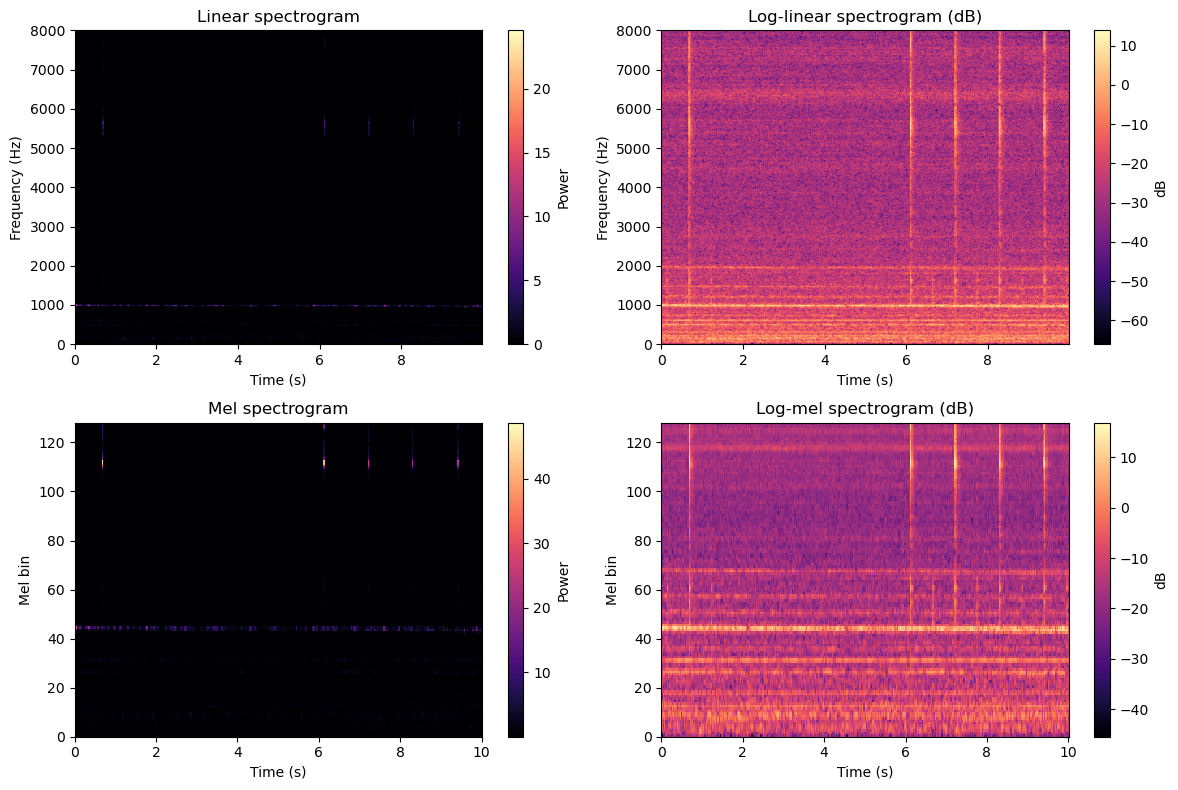

In [14]:
# 2x2 grid returns a 2D array: unpack as ((ax1, ax2), (ax3, ax4))
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8), sharey=False)

# 1) Linear spectrogram (linear magnitude)
im1 = ax1.imshow(spec_linear, aspect="auto", origin="lower", cmap="magma",
                 extent=[time_s[0], time_s[-1], freq_Hz[0], freq_Hz[-1]])
ax1.set_ylabel("Frequency (Hz)")
ax1.set_xlabel("Time (s)")
ax1.set_title("Linear spectrogram")
plt.colorbar(im1, ax=ax1, label="Power")

# 2) Linear spectrogram (log magnitude / dB)
im2 = ax2.imshow(log_spec_linear, aspect="auto", origin="lower", cmap="magma",
                 extent=[time_s[0], time_s[-1], freq_Hz[0], freq_Hz[-1]])
ax2.set_ylabel("Frequency (Hz)")
ax2.set_xlabel("Time (s)")
ax2.set_title("Log-linear spectrogram (dB)")
plt.colorbar(im2, ax=ax2, label="dB")

# 3) Mel spectrogram — y-axis: mel bin index (0 to 128)
im3 = ax3.pcolormesh(time_edges, np.arange(N_MELS + 1), mel_spec, shading="auto", cmap="magma")
ax3.set_ylabel("Mel bin")
ax3.set_xlabel("Time (s)")
ax3.set_title("Mel spectrogram")
plt.colorbar(im3, ax=ax3, label="Power")

# 4) Log-mel spectrogram — y-axis: mel bin index (0 to 128)
im4 = ax4.pcolormesh(time_edges, np.arange(N_MELS + 1), log_mel_spec, shading="auto", cmap="magma")
ax4.set_ylabel("Mel bin")
ax4.set_xlabel("Time (s)")
ax4.set_title("Log-mel spectrogram (dB)")
plt.colorbar(im4, ax=ax4, label="dB")

plt.tight_layout()
plt.show()

In [15]:
# Print numerical range of each spectrogram
print(f"Linear spectrogram (linear magnitude): min = {spec_linear.min():.2f}, max = {spec_linear.max():.2f}")
print(f"Linear spectrogram (log magnitude): min = {log_spec_linear.min():.2f}, max = {log_spec_linear.max():.2f}")
print(f"Mel spectrogram: min = {mel_spec.min():.2f}, max = {mel_spec.max():.2f}")
print(f"Log-mel spectrogram: min = {log_mel_spec.min():.2f}, max = {log_mel_spec.max():.2f}")

# Assess mean and std of each spectorgram
print(f"Linear spectrogram (linear magnitude): mean = {spec_linear.mean():.2f}, std = {spec_linear.std():.2f}")
print(f"Linear spectrogram (log magnitude): mean = {log_spec_linear.mean():.2f}, std = {log_spec_linear.std():.2f}")
print(f"Mel spectrogram: mean = {mel_spec.mean():.2f}, std = {mel_spec.std():.2f}")
print(f"Log-mel spectrogram: mean = {log_mel_spec.mean():.2f}, std = {log_mel_spec.std():.2f}")






Linear spectrogram (linear magnitude): min = 0.00, max = 24.57
Linear spectrogram (log magnitude): min = -66.10, max = 13.90
Mel spectrogram: min = 0.00, max = 48.67
Log-mel spectrogram: min = -45.47, max = 16.87
Linear spectrogram (linear magnitude): mean = 0.05, std = 0.34
Linear spectrogram (log magnitude): mean = -24.75, std = 8.59
Mel spectrogram: mean = 0.18, std = 0.94
Log-mel spectrogram: mean = -13.97, std = 6.16


In [ ]:
# Generate binary mask at spectrogram resolution with random vertical lines
import numpy as np

time_bins = 3
diff_lengths = np.random.randint(10, 50, (1, time_bins))
bandwidth = 128

mask = np.zeros((128, 320))

for i in range(time_bins):
    start_idx = np.random.randint(0, 320 - diff_lengths[0, i])
    end_idx = start_idx + diff_lengths[0, i]
    mask[:, start_idx:end_idx] = 1


print(mask.shape)

# Plot the mask
plt.imshow(mask, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.show()



In [ ]:
import torch.nn.functional as F
# Project such mask to the two latent spaces
mask = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0)


mask_fine = F.avg_pool2d(mask, kernel_size=(4, 4), stride=(4, 4))
mask_coarse = F.avg_pool2d(mask, kernel_size=(8, 8), stride=(8, 8))

print(mask_coarse.shape)
print(mask_fine.shape)

# Plot both projected masks
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(mask_coarse.squeeze().numpy(), cmap='gray')
ax1.set_xticks([])
ax1.set_yticks([])
ax2.imshow(mask_fine.squeeze().numpy(), cmap='gray')
ax2.set_xticks([])
ax2.set_yticks([])



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible random-ish ROC-like curve
rng = np.random.default_rng(7)
fpr = np.linspace(0, 1, 120)
base = 1 - (1 - fpr) ** 2.2              # concave ROC-like shape
noise = rng.normal(0, 0.015, size=fpr.size)
tpr = np.clip(base + noise, 0, 1)
tpr = np.maximum.accumulate(tpr)          # enforce monotonic increase
tpr[0], tpr[-1] = 0.0, 1.0

auc = np.trapezoid(tpr, fpr)

fig, ax = plt.subplots(figsize=(6.5, 5.2), dpi=180)
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1.2, label='Random classifier (AUC = 0.5)')
ax.plot(fpr, tpr, color='#1f77b4', lw=2.2, label=f'Example ROC (AUC = {auc:.3f})')
ax.fill_between(fpr, tpr, 0, color='#1f77b4', alpha=0.18, label='Area under curve (AUC)')

# Optional threshold markers
idxs = [12]
labels = [r'$\tau_1$']
for i, lab in zip(idxs, labels):
    ax.scatter(fpr[i], tpr[i], s=28, color='black', zorder=3)
    ax.text(fpr[i] + 0.02, tpr[i] - 0.05, lab, fontsize=10)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('Receiver Operating Characteristic (ROC) and AUC')
ax.grid(alpha=0.25)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()